In [1]:
list.of.packages <- c("tidyverse","ggfixest","ggpubr","data.table","broom")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Le chargement a nécessité le package : fixest


Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Les objets suivants sont masqués depuis ‘package:dplyr’:

    between, first, last


L'objet suivant est masqué depuis ‘package:purrr’:

    transpo

In [2]:
T_bins_labels <- c("<=17°C","17,21]","21,23]","23,25]","25,27]","27,29]","29,31]","31,33]",">33°C")
T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")

WB_bins_labels <- c("<=14°C","14,16]","16,18]","18,20]","20,22]","22,24]","24,26]","26,28]",">28°C")
WB_bins_labels_pretty <- c("≤14°C","(14,16]","(16,18]","(18,20]","(20,22]","(22,24]","(24,26]","(26,28]",">28°C")

bin_ref_T <-"17,21]"
bin_ref_WB <-"16,18]"

# Children

In [3]:
df_children <- fread("./2_Regression_datasets/output/df_reg_children.csv")
sprintf("%i rows x %i columns", nrow(df_children), ncol(df_children))
head(df_children,2)

[1] "281812 rows x 321 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Mother_id,Child_id,Resp_nb,Interview_month,Interview_year,Measured_date_CDC,Measured_date,Measured_day,Measured_month,Measured_year,Birth_month,Birth_year,Child_female,Child_birth_order,Child_alive_age_month,Child_hemo_level_alti,Child_weight_for_height_zscore,Child_diarrhea,Child_fever,Child_cough,Child_still_breastfeeding,Child_given_plain_water,Child_given_juice,Child_given_milk,Child_given_baby_formula,Child_given_fortified_baby_food,Child_given_soup,Child_given_other_liquid,Child_given_chicken_duck_birds,Child_given_bread_noodles_grains,Child_given_potatoes_cassava_tubers,Child_given_eggs,Child_given_pumkins_carrots_squash,Child_given_green_vegetables,Child_given_mangoes_papaya_vitaminAfruits,Child_given_other_fruits,Child_given_liver_heart_organs,Child_given_fish_sellfish,Child_given_beans_peas_lentils_nuts,Child_given_cheese_yogurt_milk_products,Child_given_other_solid_semisolid_food,Child_given_other_meat,Child_given_yogurt,Child_iron_supplem_7d,Mother_no_educ,Mother_prim_educ,Mother_second_educ,Mother_higher_educ,Mother_hindu,Mother_muslim,Mother_not_hindu_nor_muslim,Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,Mother_ethni_other,Mother_height,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,Interview_cdc,Wasted,Age_rounded,Children_anemia,Child_severe_anemia,Child_moderate_anemia,Child_mild_anemia,Child_no_anemia,Season,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_

In [4]:
df_reg_children <- df_children %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                       WB_i30_bin=factor(gsub("\\(","",WB_i30_bin),levels=WB_bins_labels)
)

# Women

In [5]:
df_women <- fread("./2_Regression_datasets/output/df_reg_women.csv")
sprintf("%i rows x %i columns", nrow(df_women), ncol(df_women))
head(df_women,2)

[1] "973462 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Women_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Currently_pregnant,Blood_hemo_level_alti,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Body_mass_index,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Women_anemia,Women_severe_anemia,Women_moderate_anemia,Women_mild_anemia,Women_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T

In [6]:
df_reg_women <- df_women %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                       WB_i30_bin=factor(gsub("\\(","",WB_i30_bin),levels=WB_bins_labels)
)

# Men

In [7]:
df_men <- fread("./2_Regression_datasets/output/df_reg_men.csv")
sprintf("%i rows x %i columns", nrow(df_men), ncol(df_men))
head(df_men,2)

[1] "150101 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Men_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Profession,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Blood_hemo_level_alti,Body_mass_index,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Men_anemia,Men_severe_anemia,Men_moderate_anemia,Men_mild_anemia,Men_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T_MaxBin_27_29_Ndays_

In [8]:
df_reg_men <- df_men %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                       WB_i30_bin=factor(gsub("\\(","",WB_i30_bin),levels=WB_bins_labels)
)

# Air Temperature

In [9]:
reg_children_T_WHZ <- feols(Child_weight_for_height_zscore ~ i(T_i30_bin,ref=bin_ref_T) + P_tot_30 + 
                                        Child_female + Child_birth_order + Child_alive_age_month +
                                        Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                                        Mother_muslim + Mother_not_hindu_nor_muslim  + 
                                        Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                    df_reg_children)

NOTES: 27,686 observations removed because of NA values (LHS: 11,783, RHS: 16,652).
       43/8 fixed-effect singletons were removed (43 observations).



In [10]:
reg_women_T_BMI <- feols(Body_mass_index ~ i(T_i30_bin,ref=bin_ref_T) + P_tot_30 +
                                        Current_age + N_year_educ + Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                    df_reg_women)

NOTES: 100,923 observations removed because of NA values (LHS: 43,778, RHS: 59,850).
       15/1 fixed-effect singletons were removed (15 observations).



In [11]:
reg_men_T_BMI <- feols(Body_mass_index ~ i(T_i30_bin,ref=bin_ref_T) + P_tot_30 +
                                        Current_age + N_year_educ + Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                    df_reg_men)

NOTES: 9,928 observations removed because of NA values (LHS: 409, RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



# Wet-bulb

In [12]:
reg_children_WB_WHZ <- feols(Child_weight_for_height_zscore ~ i(WB_i30_bin,ref=bin_ref_WB) + P_tot_30 + 
                                        Child_female + Child_birth_order + Child_alive_age_month +
                                        Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                                        Mother_muslim + Mother_not_hindu_nor_muslim  + 
                                        Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                    df_reg_children)

NOTES: 27,686 observations removed because of NA values (LHS: 11,783, RHS: 16,652).
       43/8 fixed-effect singletons were removed (43 observations).



In [13]:
reg_women_WB_BMI <- feols(Body_mass_index ~  i(WB_i30_bin,ref=bin_ref_WB) + P_tot_30 +
                                        Current_age + N_year_educ + Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                    df_reg_women)

NOTES: 100,923 observations removed because of NA values (LHS: 43,778, RHS: 59,850).
       15/1 fixed-effect singletons were removed (15 observations).



In [14]:
reg_men_WB_BMI <- feols(Body_mass_index ~ i(WB_i30_bin,ref=bin_ref_WB) + P_tot_30 +
                                        Current_age + N_year_educ + Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                    df_reg_men)

NOTES: 9,928 observations removed because of NA values (LHS: 409, RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [15]:
varT <- "T_i30_bin"
varWB <- "WB_i30_bin"

dict_levels_T <- setNames(paste0("T: ",T_bins_labels_pretty), paste0(varT, "::", T_bins_labels))
dict_levels_WB <- setNames(paste0("WBGT: ",WB_bins_labels_pretty), paste0(varWB, "::", WB_bins_labels))

dict <- c(dict_levels_T, dict_levels_WB)

In [16]:
etable(reg_children_T_WHZ,reg_women_T_BMI,reg_men_T_BMI,
       reg_children_WB_WHZ,reg_women_WB_BMI,reg_men_WB_BMI,
       tex=TRUE,
       fitstat = ~ n + r2 + my,
       drop="%!_bin",
       dict = dict
      )

\begingroup
\centering
\begin{tabular}{lcccccc}
   \tabularnewline \midrule \midrule
   Dependent Variables: & Child\_weight\_for\_height\_zscore & \multicolumn{2}{c}{Body\_mass\_index} & Child\_weight\_for\_height\_zscore & \multicolumn{2}{c}{Body\_mass\_index}\\
   Model:                         & (1)             & (2)      & (3)            & (4)             & (5)      & (6)\\  
   \midrule
   \emph{Variables}\\
   T: ≤17°C                       & 0.0299          & 0.0332   & 0.1759$^{*}$   &                 &          &   \\   
                                  & (0.0260)        & (0.0463) & (0.1032)       &                 &          &   \\   
   T: (21,23]                     & -0.0109         & -0.0210  & -0.0891        &                 &          &   \\   
                                  & (0.0261)        & (0.0399) & (0.0913)       &                 &          &   \\   
   T: (23,25]                     & -0.0121         & 0.0031   & 0.1617         &                 &       

# Plots

## Age heterogeneity children

In [17]:
reg_child_age_WHZ <- feols(Child_weight_for_height_zscore ~ Age_rounded + i(T_i30_bin,Age_rounded,ref=bin_ref_T) + P_tot_30 + 
                                        Child_female + Child_birth_order +
                                        #Child_alive_age_month + 
                                        Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                                        Mother_muslim + Mother_not_hindu_nor_muslim  + 
                                        Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                        df_reg_children%>%mutate(Age_rounded=factor(Age_rounded)))

NOTES: 27,686 observations removed because of NA values (LHS: 11,783, RHS: 16,652).
       43/8 fixed-effect singletons were removed (43 observations).



In [18]:
etable(reg_child_age_WHZ)

,,reg_child_age_WHZ
,<chr>,<chr>
1,Dependent Var.:,Child_weight_for_height_zscore
2,,
3,Age_rounded12,-0.0053 (0.1042)
4,Age_rounded18,0.0063 (0.1052)
5,Age_rounded24,-0.0081 (0.1032)
6,Age_rounded30,-0.0873 (0.1087)
7,Age_rounded36,-0.0239 (0.1085)
8,Age_rounded42,-0.0087 (0.1076)
9,Age_rounded48,0.0403 (0.1073)


In [19]:
age_list <- c(":6",":12",":18",":24",":30",":36",":42",":48",":54",":59")

In [20]:
extract_estimate <- function(df,group_name,age_name,Tbin_name){
            row <- tidy(df,conf.int=TRUE)%>%
                         filter(grepl(Tbin_name,term)&grepl(age_name,term))%>% 
                         mutate(age = age_name, 
                                group = group_name,
                                Tbin = Tbin_name)
            return(row)
}

In [21]:
children_estimates <- data.frame()
for (age_name in age_list){
    for (Tbin_name in T_bins_labels){
        row_estimate <- extract_estimate(reg_child_age_WHZ,"Children",age_name,Tbin_name)
        children_estimates <- rbind(children_estimates,row_estimate)
        }
    }

In [22]:
all_children_estimates <- children_estimates %>%
                   mutate(Tbin=factor(Tbin,levels=T_bins_labels),
                          age=sub(":","",age),
                          age=factor(age,levels=c("6","12","18","24","30","36","42","48","54","59")))
all_children_estimates

term,estimate,std.error,statistic,p.value,conf.low,conf.high,age,group,Tbin
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<fct>
T_i30_bin::<=17°C:Age_rounded::6,-0.0154798646,0.13573386,-0.114045714,0.9092373781,-0.28201818,0.2510584540,6,Children,<=17°C
"T_i30_bin::21,23]:Age_rounded::6",0.0082389102,0.13813745,0.059642844,0.9524587422,-0.26301930,0.2794971208,6,Children,"21,23]"
"T_i30_bin::23,25]:Age_rounded::6",0.1655843576,0.14526587,1.139871054,0.2547671063,-0.11967181,0.4508405278,6,Children,"23,25]"
"T_i30_bin::25,27]:Age_rounded::6",0.1620932890,0.14330120,1.131136988,0.2584217780,-0.11930490,0.4434914761,6,Children,"25,27]"
"T_i30_bin::27,29]:Age_rounded::6",-0.1309671452,0.13554165,-0.966250182,0.3342845532,-0.39712803,0.1351937429,6,Children,"27,29]"
"T_i30_bin::29,31]:Age_rounded::6",-0.2144746971,0.14589569,-1.470055051,0.1420390336,-0.50096764,0.0720182462,6,Children,"29,31]"
"T_i30_bin::31,33]:Age_rounded::6",-0.2378954781,0.17120812,-1.389510493,0.1651615193,-0.57409402,0.0983030604,6,Children,"31,33]"
T_i30_bin::>33°C:Age_rounded::6,-0.3803352383,0.17819129,-2.134420987,0.0331882654,-0.73024652,-0.0304239549,6,Children,>33°C
T_i30_bin::<=17°C:Age_rounded::12,0.0163048197,0.05609155,0.290682296,0.7713886291,-0.09384122,0.1264508582,12,Children,<=17°C


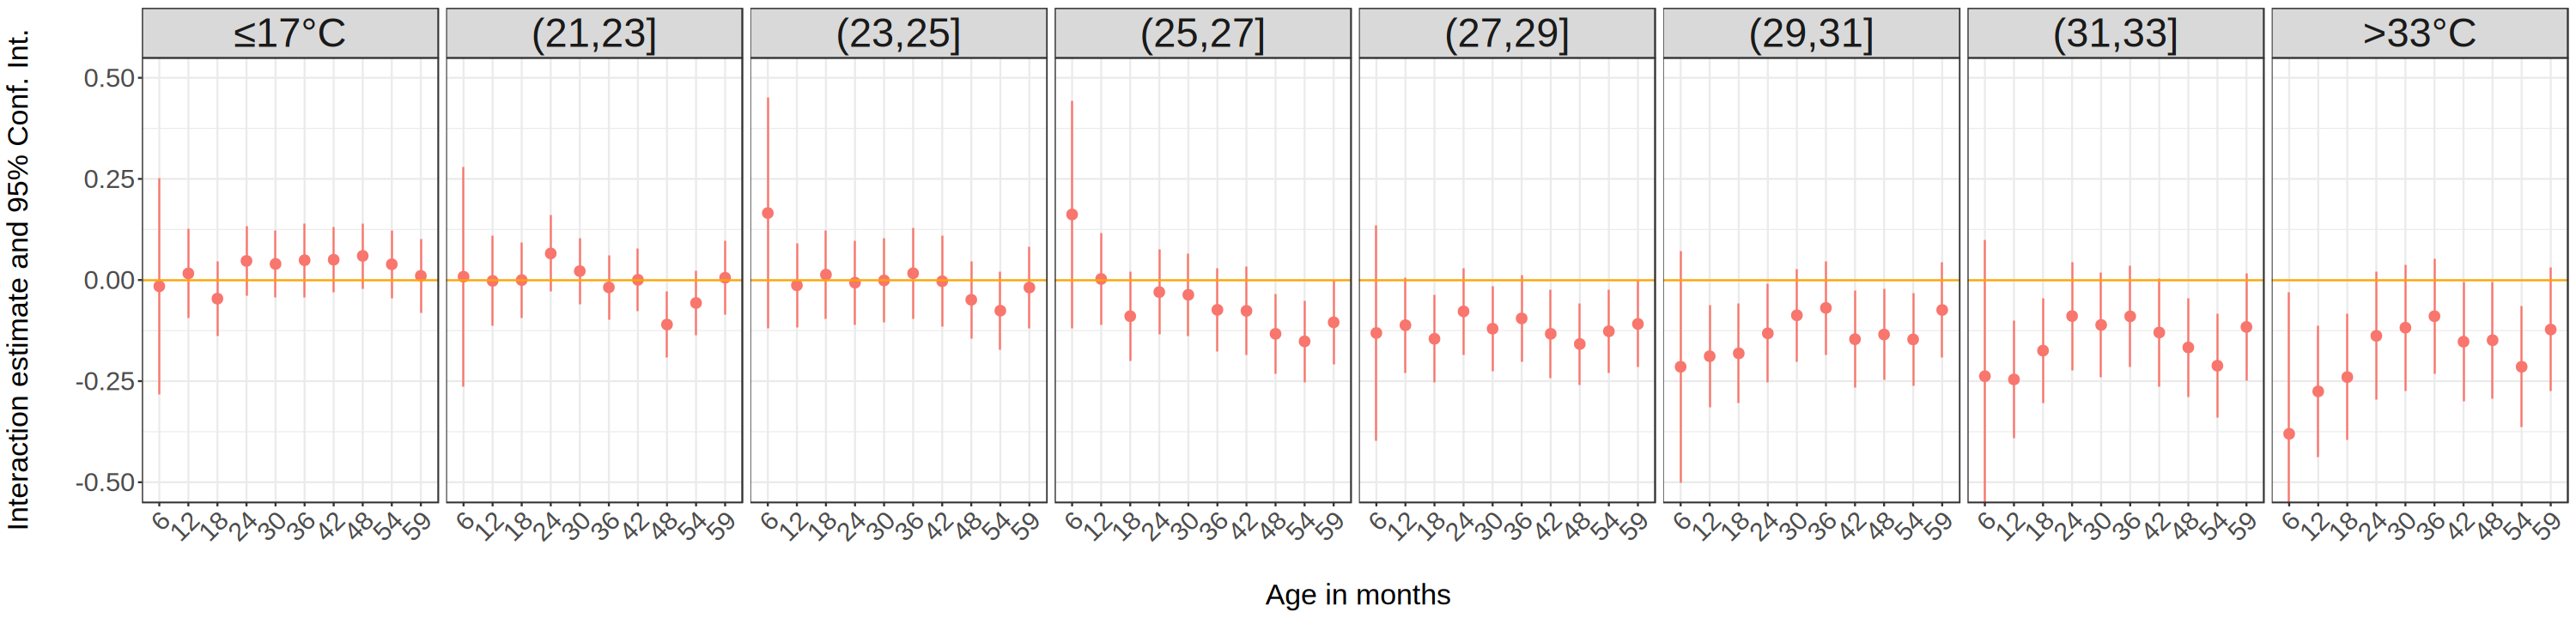

In [23]:
options(repr.plot.width=25, repr.plot.height=6, scipen=9999)

plot_estimates <- ggplot(all_children_estimates,aes(x=age, y=estimate, ymin=conf.low, ymax=conf.high, color = group)) +
                          geom_pointrange(position = position_dodge(width = 1/4)) +
                          geom_hline(yintercept = 0, col = "orange") +
                          labs(#title ="Weight-for-Height Z-score - Interaction age and air temperature bin \n",
                               x="\n Age in months", 
                               y="Interaction estimate and 95% Conf. Int.\n", 
                               color="Group")+
                          coord_cartesian(y=c(-0.5,0.5))+
                          facet_grid(cols = vars(Tbin),
                                     labeller=as_labeller(setNames(T_bins_labels_pretty,T_bins_labels)))+
                          theme_bw() +
                          theme(plot.title = element_text(size = 30, face="bold",hjust=0.5),
                                plot.subtitle = element_text(size = 28),
                                legend.position="none",
                                legend.title = element_text(size = 28,face ="bold"),
                                legend.text = element_text(size = 28),
                                strip.text.x = element_text(size = 28),
                                axis.text.x = element_text(size = 18,angle=45,hjust=1),
                                axis.text.y = element_text(size = 18),
                                axis.title.x = element_text(size = 20, hjust = 0.5),
                                axis.title.y = element_text(size = 20, hjust = 0.5))
plot_estimates

In [24]:
ggsave("./3_output/img/hetero_children_age_WHZ.png", width=25, height=6.5, plot_estimates)

# Heterogeneity effect Air temp>29

### Children

In [25]:
reg_child_age_hemo <- feols(Child_hemo_level_alti ~ factor(Age_rounded) + i(Age_rounded,Ti30_sup29) + P_tot_30 + 
                                        Child_female + Child_birth_order + Child_alive_age_month +
                                        Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                                        Mother_muslim + Mother_not_hindu_nor_muslim  + 
                                        Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                        df_reg_children%>%mutate(Ti30_sup29 = ifelse(T_i30>=29,1,0)))

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).



In [26]:
options(repr.plot.width=11, repr.plot.height=7, scipen=9999)

plot_child_age_hemo <- ggiplot(reg_child_age_hemo, ref.line=0)+
                          labs(title="Hemoglobin level (g/L) \n",
                               subtitle ="Air temperature >29°C",
                               x="\n Age in months", 
                               y = "Estimate and 95% Conf.Int. \n")+
                          theme(legend.position="none",
                                plot.title = element_text(size=25),
                                plot.subtitle = element_text(size=22),
                                axis.title.x = element_text(size = 20),
                                axis.text.x =  element_text(size = 20, angle=40, hjust=1),
                                axis.title.y = element_text(size = 20),
                                axis.text.y =  element_text(size = 20)
                                )

In [27]:
reg_child_age_WHZ <- feols(Child_weight_for_height_zscore ~ factor(Age_rounded) + i(Age_rounded,Ti30_sup29) + P_tot_30 + 
                                        Child_female + Child_birth_order + Child_alive_age_month +
                                        Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                                        Mother_muslim + Mother_not_hindu_nor_muslim  + 
                                        Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                        df_reg_children%>%mutate(Ti30_sup29 = ifelse(T_i30>=29,1,0)))

NOTES: 27,686 observations removed because of NA values (LHS: 11,783, RHS: 16,652).
       43/8 fixed-effect singletons were removed (43 observations).



In [28]:
options(repr.plot.width=11, repr.plot.height=7, scipen=9999)

plot_child_age_WHZ <- ggiplot(reg_child_age_WHZ, ref.line=0)+
                          labs(title="Weight-for-Height Z-score \n",
                               subtitle ="Air temperature >29°C",
                               x="\n Age in months", 
                               y = "Estimate and 95% Conf.Int. \n")+
                          theme(legend.position="none",
                                plot.title = element_text(size=25),
                                plot.subtitle = element_text(size=22),
                                axis.title.x = element_text(size = 20),
                                axis.text.x =  element_text(size = 20, angle=40, hjust=1),
                                axis.title.y = element_text(size = 20),
                                axis.text.y =  element_text(size = 20)
                                )

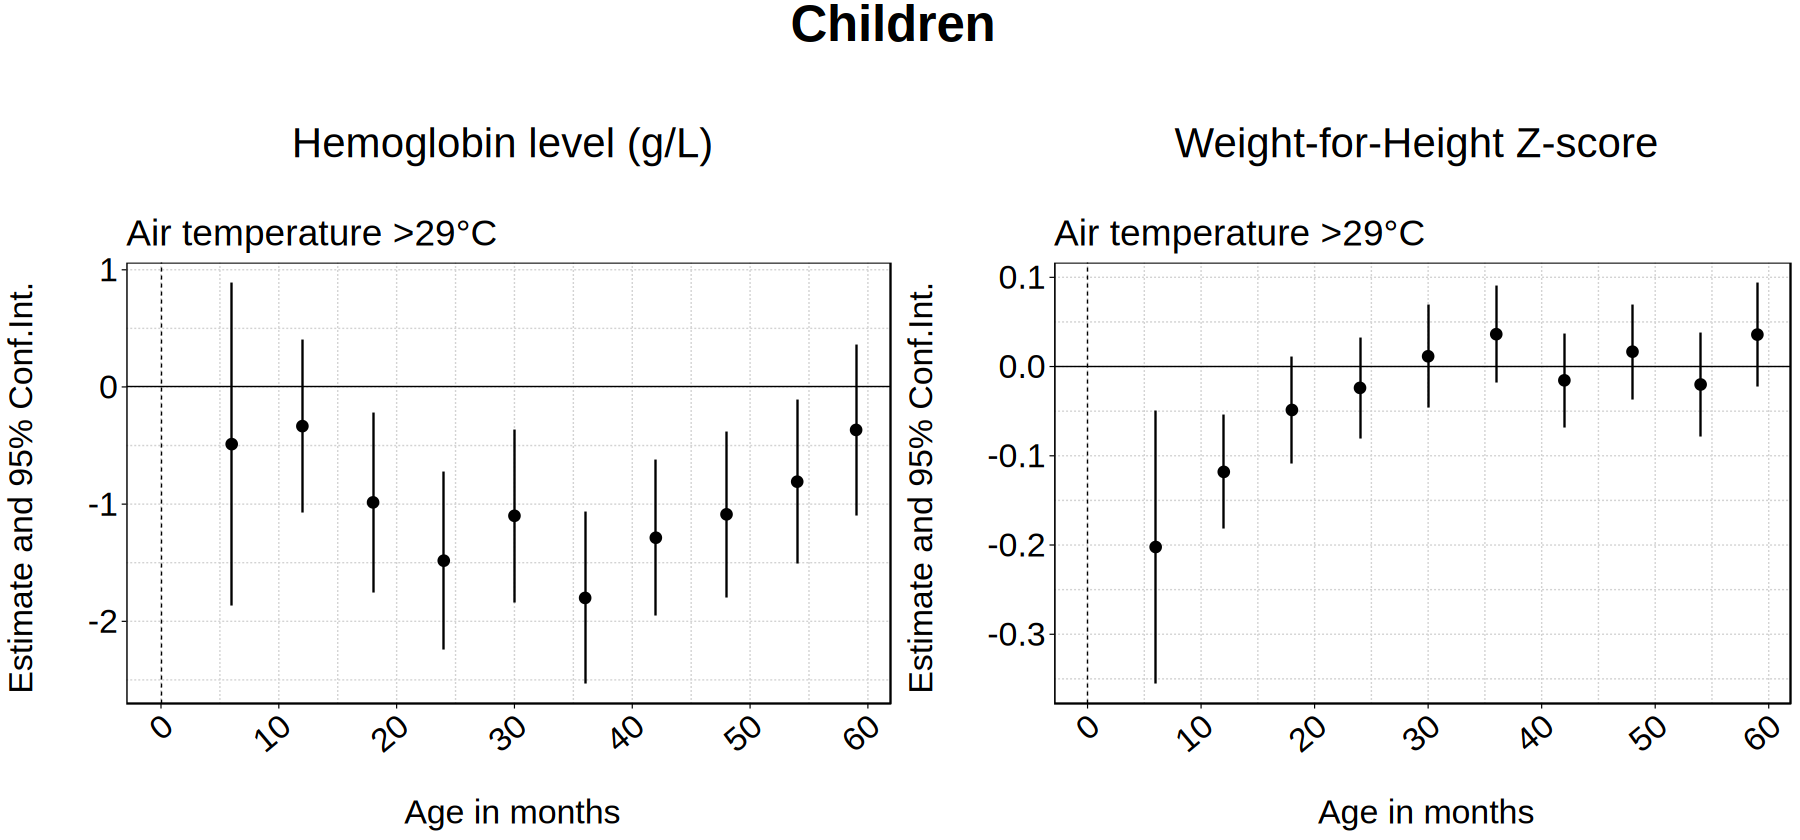

In [29]:
options(repr.plot.width=15, repr.plot.height=7, scipen=9999)

plot_children <- annotate_figure(ggarrange(plot_child_age_hemo,plot_child_age_WHZ,nrow=1,ncol=2),
                                 top=text_grob("Children \n", face="bold", size=30))
plot_children

In [30]:
ggsave("./3_output/img/children_comp_hemo_WHZ_sup29.png", width=18, height=7, plot_children)

# BMI interaction - Adults

In [31]:
df_reg_men %>% group_by(BMI_category)%>%summarize(N=n(), BMI= mean(Body_mass_index))

BMI_category,N,BMI
<chr>,<int>,<dbl>
Normal,94398,21.60665
Obese,4353,33.29200
Overweight,24423,26.81446
Underweight,26518,17.11218
NA,409,NA


In [32]:
df_reg_women %>% group_by(BMI_category)%>%summarize(N=n(), BMI= mean(Body_mass_index))

BMI_category,N,BMI
<chr>,<int>,<dbl>
,43778,NA
Normal,552826,21.44126
Obese,42296,33.23910
Overweight,141021,26.97030
Underweight,193541,17.03588


In [33]:
reg_men_BMI_cat <- feols(Body_mass_index ~ BMI_category + i(T_i30_bin,BMI_category,ref=bin_ref_T) + P_tot_30 +
                                        Current_age + N_year_educ + Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim  + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                      data=df_reg_men)

NOTES: 9,928 observations removed because of NA values (LHS: 409, RHS: 9,928).
       13/1 fixed-effect singletons were removed (13 observations).



In [34]:
reg_men_hemo_BMI_cat <- feols(Blood_hemo_level_alti ~ BMI_category + i(T_i30_bin,BMI_category,ref=bin_ref_T) + P_tot_30 +
                                        Current_age + N_year_educ + Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim  + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                      data=df_reg_men)

NOTES: 9,928 observations removed because of NA values (RHS: 9,928).
       13/1 fixed-effect singletons were removed (13 observations).



In [35]:
reg_women_BMI_cat <- feols(Body_mass_index ~ BMI_category + i(T_i30_bin,BMI_category,ref=bin_ref_T) + P_tot_30 +
                                        Current_age + N_year_educ + Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim  + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                      data=df_reg_women)

NOTES: 100,923 observations removed because of NA values (LHS: 43,778, RHS: 59,850).
       15/1 fixed-effect singletons were removed (15 observations).



In [36]:
reg_women_hemo_BMI_cat <- feols(Blood_hemo_level_alti ~ BMI_category + i(T_i30_bin,BMI_category,ref=bin_ref_T) + P_tot_30 +
                                        Current_age + N_year_educ + Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim  + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                      data=df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



# Extract interaction estimates

In [37]:
BMI_cat_list <- c("Normal","Obese","Overweight","Underweight")

In [38]:
extract_estimate <- function(df,group_name,BMI_cat,Tbin_name){
            row <- tidy(df,conf.int=TRUE)%>%
                         filter(grepl(Tbin_name,term)&grepl(BMI_cat,term))%>% 
                         mutate(BMI_category = BMI_cat, 
                                group = group_name,
                                Tbin = Tbin_name)
            return(row)
}

In [39]:
get_reg_estimates <- function(reg,group){
    estimates <- data.frame()
    for (BMI_cat in BMI_cat_list){
        for (Tbin_name in T_bins_labels){
            row_estimate <- extract_estimate(reg,group,BMI_cat,Tbin_name)
            estimates <- rbind(estimates,row_estimate)
            }
        }
    all_estimates <- estimates %>%
                   mutate(Tbin=factor(Tbin,levels=T_bins_labels),
                          BMI_category=factor(BMI_category,levels=BMI_cat_list))
    return(all_estimates)
}

#### Estimates on BMI

In [40]:
estimates_BMI_men <- get_reg_estimates(reg_men_BMI_cat,"Men")

In [41]:
estimates_BMI_women <- get_reg_estimates(reg_women_BMI_cat,"Women")

In [42]:
all_estimates_BMI <- rbind(estimates_BMI_men,estimates_BMI_women)
head(all_estimates_BMI)

term,estimate,std.error,statistic,p.value,conf.low,conf.high,BMI_category,group,Tbin
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<fct>
T_i30_bin::<=17°C:BMI_category::Normal,0.024819889,0.05758375,0.43102242,0.6665974,-0.08825637,0.13789615,Normal,Men,<=17°C
"T_i30_bin::21,23]:BMI_category::Normal",-0.057700760,0.04517378,-1.27730645,0.2019580,-0.14640776,0.03100624,Normal,Men,"21,23]"
"T_i30_bin::23,25]:BMI_category::Normal",0.035515074,0.06012535,0.59068384,0.5549411,-0.08255208,0.15358223,Normal,Men,"23,25]"
"T_i30_bin::25,27]:BMI_category::Normal",0.031355037,0.06287226,0.49871020,0.6181552,-0.09210617,0.15481625,Normal,Men,"25,27]"
"T_i30_bin::27,29]:BMI_category::Normal",0.030854490,0.07034491,0.43861725,0.6610871,-0.10728064,0.16898962,Normal,Men,"27,29]"
"T_i30_bin::29,31]:BMI_category::Normal",0.003735839,0.07889892,0.04734968,0.9622493,-0.15119666,0.15866834,Normal,Men,"29,31]"


#### Estimates on hemoglobin level

In [43]:
estimates_hemo_BMI_men <- get_reg_estimates(reg_men_hemo_BMI_cat,"Men")

In [44]:
estimates_hemo_BMI_women <- get_reg_estimates(reg_women_hemo_BMI_cat,"Women")

In [45]:
all_estimates_hemo_BMI <- rbind(estimates_hemo_BMI_men,estimates_hemo_BMI_women)

# Plot

In [46]:
theme_perso <- function(...) {
                  theme(plot.title = element_text(size = 30, face="bold",hjust=0.5),
                                plot.subtitle = element_text(size = 28),
                                legend.position="top",
                                legend.title = element_text(size = 28,face ="bold"),
                                legend.text = element_text(size = 28),
                                strip.text.x = element_text(size = 28),
                                axis.text.x = element_text(size = 18,angle=45,hjust=1),
                                axis.text.y = element_text(size = 18),
                                axis.title.x = element_text(size = 20, hjust = 0.5),
                                axis.title.y = element_text(size = 20, hjust = 0.5))
                }

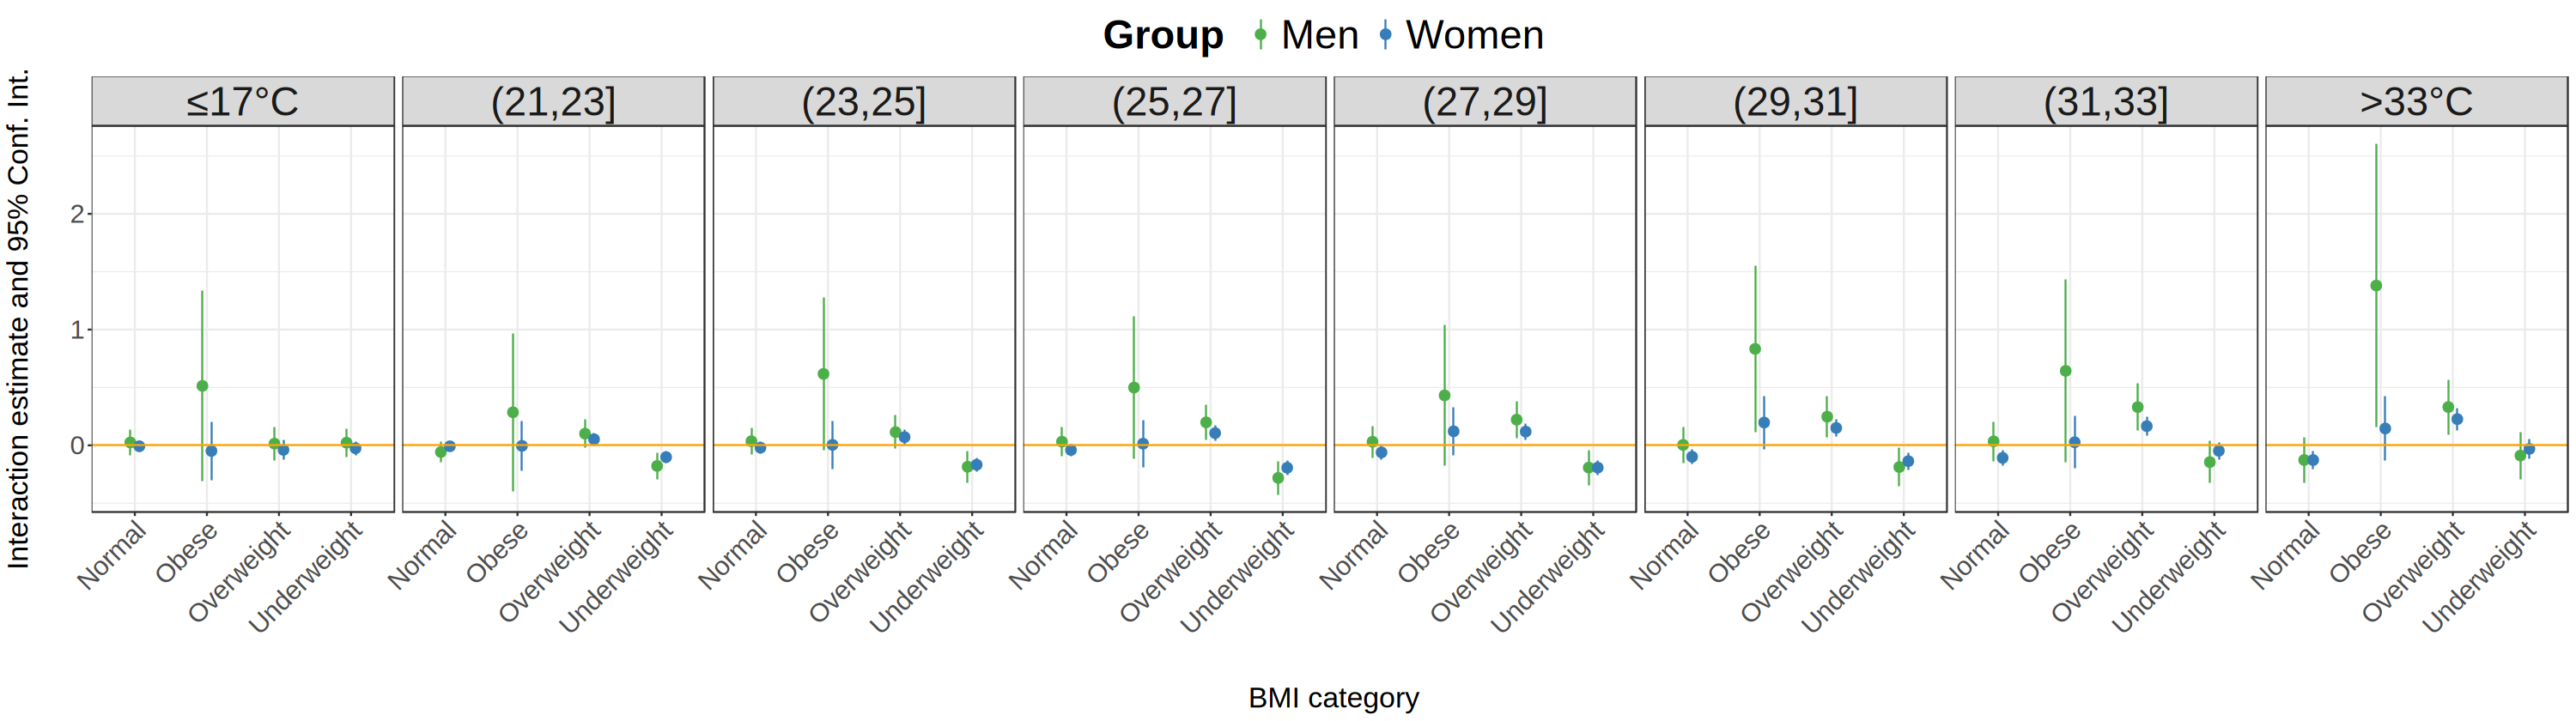

In [47]:
options(repr.plot.width=25, repr.plot.height=7, scipen=9999)

plot_BMI <- ggplot(all_estimates_BMI,aes(x=BMI_category, y=estimate, ymin=conf.low, ymax=conf.high, color = group)) +
                          geom_pointrange(position = position_dodge(width = 1/4)) +
                          geom_hline(yintercept = 0, col = "orange") +
                          labs(#title ="Body mass index (BMI) - Interaction BMI category and air temperature bin \n",
                               x="\n BMI category", 
                               y="Interaction estimate and 95% Conf. Int.\n", 
                               color="Group")+
                          scale_color_manual(values = c('#4DAF4A','#377EB8'),
                                             na.value="white")+
                          facet_grid(cols = vars(Tbin), 
                                     labeller=as_labeller(setNames(T_bins_labels_pretty,T_bins_labels)))+
                          theme_bw() +
                          theme_perso()
plot_BMI

In [48]:
ggsave("./3_output/img/hetero_adults_BMI_cat_BMI.png", width=25, height=7, plot_BMI)

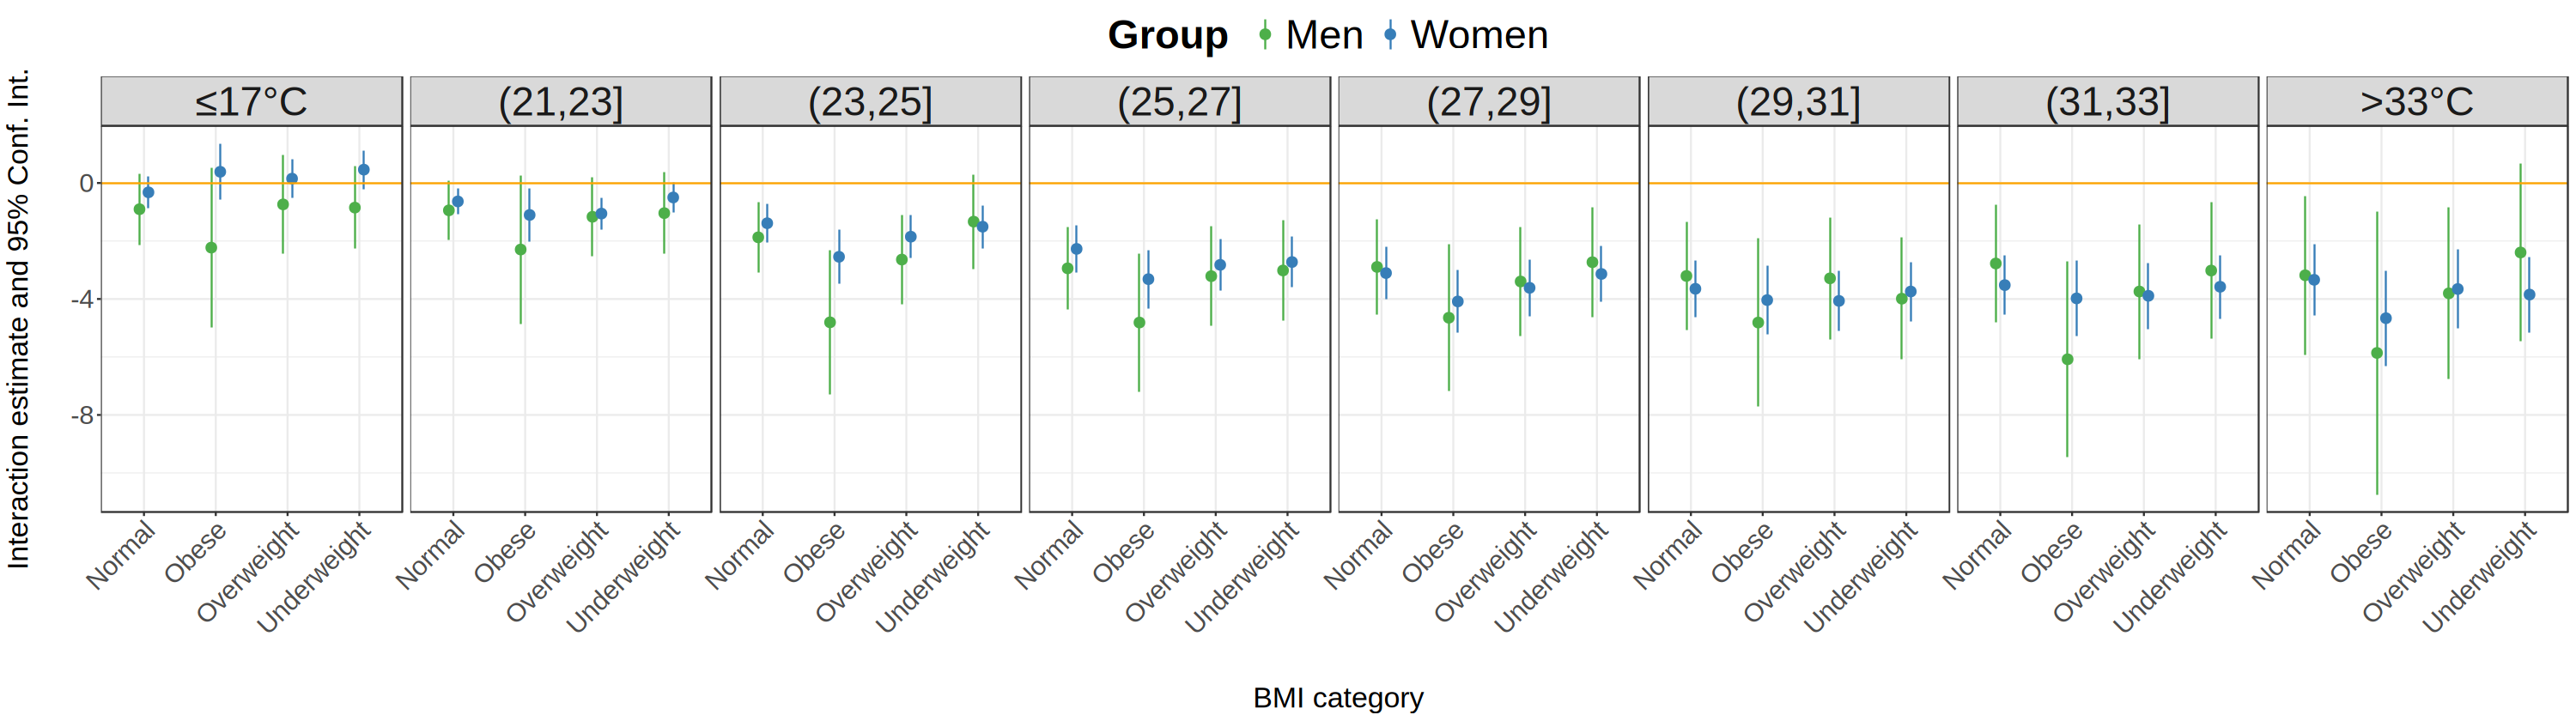

In [49]:
options(repr.plot.width=25, repr.plot.height=7, scipen=9999)

plot_hemo <- ggplot(all_estimates_hemo_BMI,aes(x=BMI_category, y=estimate, ymin=conf.low, ymax=conf.high, color = group)) +
                          geom_pointrange(position = position_dodge(width = 1/4)) +
                          geom_hline(yintercept = 0, col = "orange") +
                          labs(#title ="Hemoglobin level (g/L) - Interaction BMI category and air temperature bin \n",
                               x="\n BMI category", 
                               y="Interaction estimate and 95% Conf. Int.\n", 
                               color="Group")+
                          scale_color_manual(values = c('#4DAF4A','#377EB8'),
                                             na.value="white")+
                          facet_grid(cols = vars(Tbin), 
                                     labeller=as_labeller(setNames(T_bins_labels_pretty,T_bins_labels)))+
                          theme_bw() +
                          theme_perso()
plot_hemo

In [50]:
ggsave("./3_output/img/hetero_adults_BMI_cat_hemo.png", width=25, height=7, plot_hemo)